# Expolrotary data analysis

## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
import plotly.express as px

## Load Data

In [3]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

## Data merging

In [4]:
df = sales_train.merge(items, on='item_id', how='left')
df = df.merge(item_categories, on='item_category_id', how='left')
df = df.merge(shops, on='shop_id', how='left')

## Modeling target variables distributions

### Distribution of monthly item counts by date block number

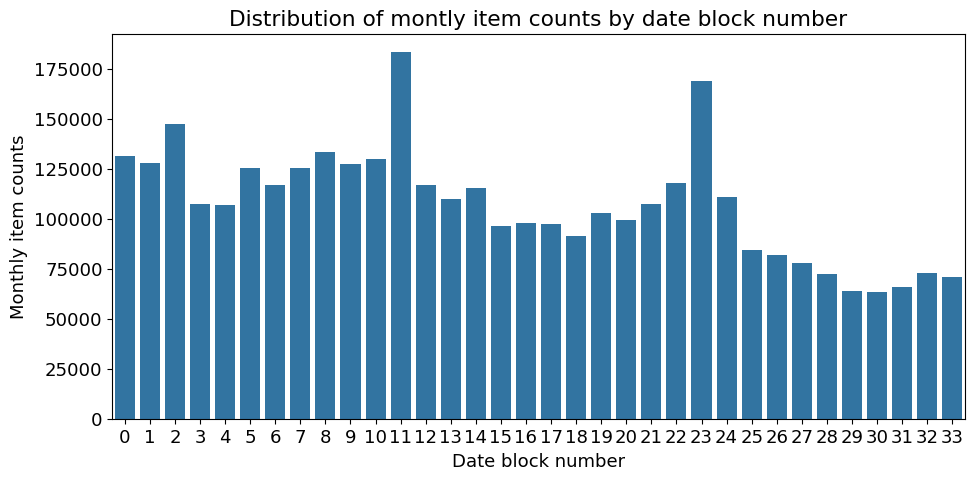

In [5]:
mpl.rc("font", size = 13)
figure, ax = plt.subplots()
figure.set_size_inches(11, 5)

group_month_sum = df.groupby("date_block_num").agg({"item_cnt_day": "sum"}).reset_index()

sns.barplot(x = "date_block_num", y = "item_cnt_day", data = group_month_sum)
ax.set(title = "Distribution of montly item counts by date block number",
       xlabel = "Date block number",
       ylabel = "Monthly item counts");

### Distribution of total item counts by category id 

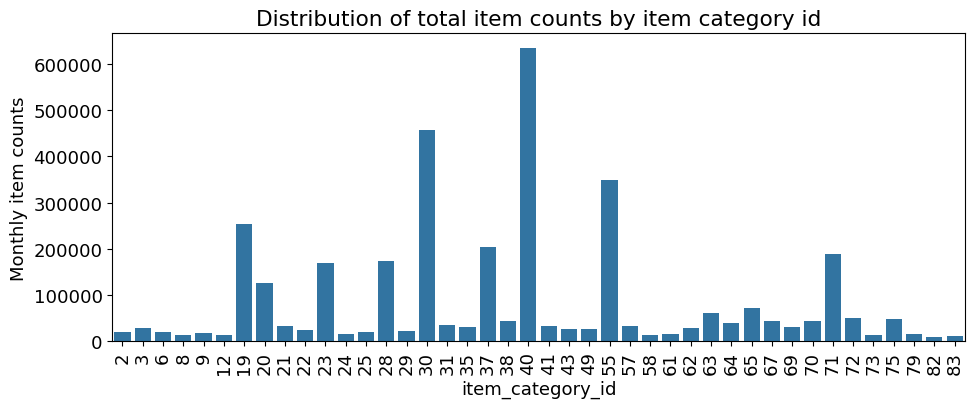

In [6]:
figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

group_cat_sum = df.groupby("item_category_id").agg({"item_cnt_day": "sum"}).reset_index()
group_cat_sum = group_cat_sum[group_cat_sum["item_cnt_day"] > 10000]

sns.barplot(x = "item_category_id", y = "item_cnt_day", data = group_cat_sum)
ax.set(title = "Distribution of total item counts by item category id",
       xlabel = "item_category_id",
       ylabel = "Monthly item counts");
ax.tick_params(axis = "x", labelrotation = 90)

Let's check what categories are the best

In [72]:
categories = [19, 20, 23, 28, 30, 37, 40, 55, 71]
result = (
    df.query("item_category_id in @categories")
    [['item_category_id', 'item_category_name']]
    .drop_duplicates()
    .sort_values('item_category_id')
    .reset_index(drop=True)
)
print(result.to_string(index=False))

 item_category_id                       item_category_name
               19                               Игры - PS3
               20                               Игры - PS4
               23                          Игры - XBOX 360
               28         Игры PC - Дополнительные издания
               30            Игры PC - Стандартные издания
               37                           Кино - Blu-Ray
               40                               Кино - DVD
               55      Музыка - CD локального производства
               71 Подарки - Сумки, Альбомы, Коврики д/мыши


### Checked the most expensive categories

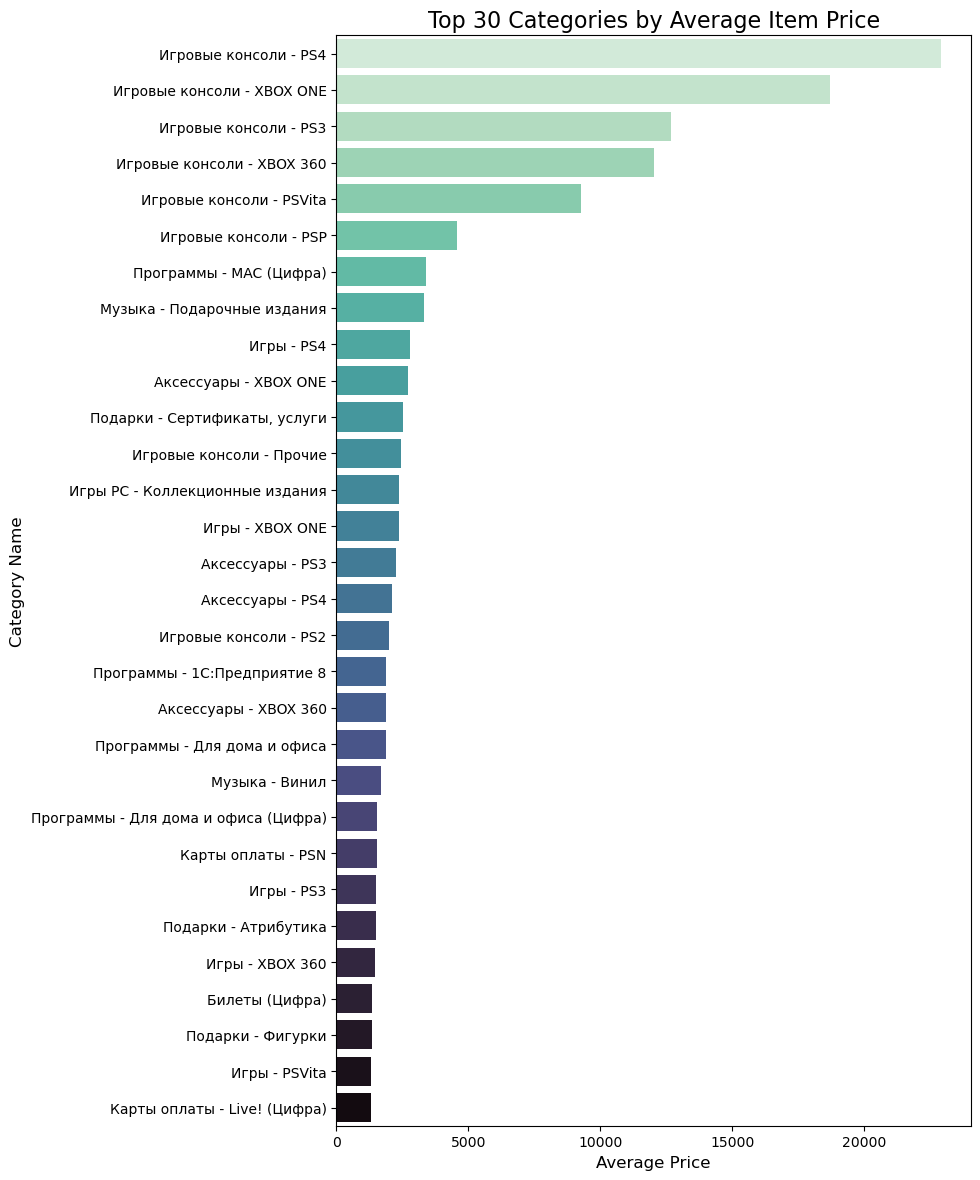

In [7]:
avg_price = df.groupby("item_category_name")["item_price"].mean().sort_values(ascending=False).head(30)
plt.figure(figsize=(10, 12))
sns.barplot(x=avg_price.values, y=avg_price.index, hue=avg_price.index, palette="mako_r", legend=False)
plt.title("Top 30 Categories by Average Item Price", fontsize=16)
plt.xlabel("Average Price", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

We can see that the consoles is the most expensive category, but is it the most valuable to sale?

### Check the best selling products

In [8]:
most_popular = df.groupby("item_id")["item_cnt_day"].sum().sort_values(ascending=False)

C:\Users\SUPER\AppData\Local\Temp\ipykernel_8644\3500436897.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


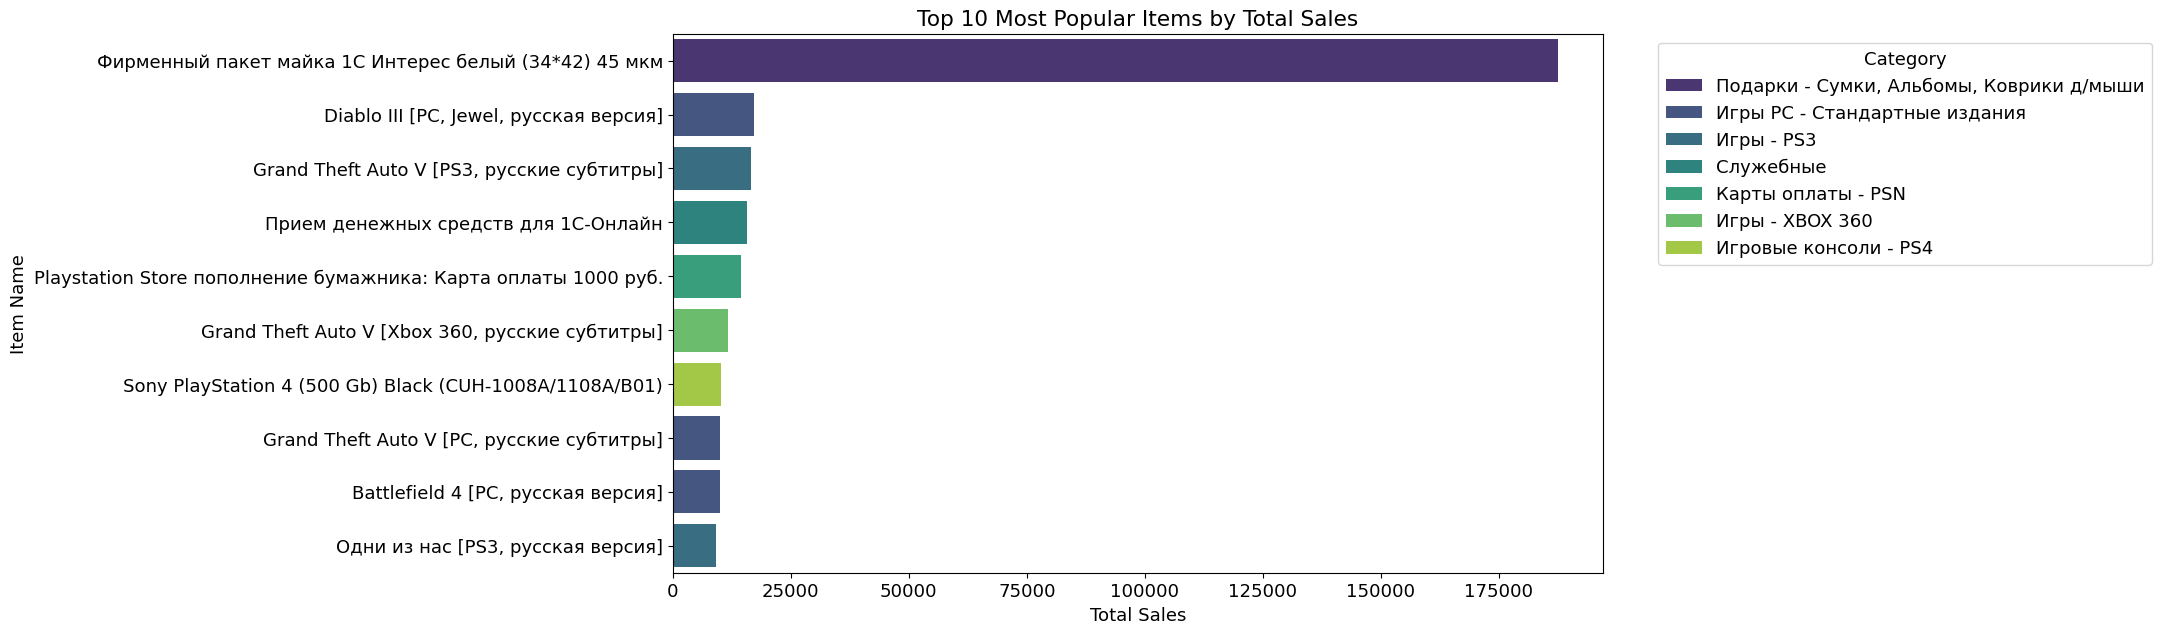

In [9]:
top_10 = most_popular.head(10).reset_index()
top_10 = top_10.merge(items[['item_id', 'item_name', 'item_category_id']], on='item_id', how='left')

top_10 = top_10.merge(item_categories[['item_category_id', 'item_category_name']], on='item_category_id', how='left')

plt.figure(figsize=(12,7))
sns.barplot(x='item_cnt_day', y='item_name', data=top_10,
            palette="viridis", hue='item_category_name')

plt.title("Top 10 Most Popular Items by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Item Name")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')  # Легенда справа
plt.tight_layout()
plt.show()

Best and worst shops/items

C:\Users\SUPER\AppData\Local\Temp\ipykernel_8644\3287022074.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axs[0, 0], data=top_items, x='item_name', y='item_cnt_day', palette='Blues_r')
C:\Users\SUPER\AppData\Local\Temp\ipykernel_8644\3287022074.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axs[0, 1], data=top_shops, x='shop_name', y='item_cnt_day', palette='Greens_r')
C:\Users\SUPER\AppData\Local\Temp\ipykernel_8644\3287022074.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axs[1, 0], data=bottom_shops, x='shop_na

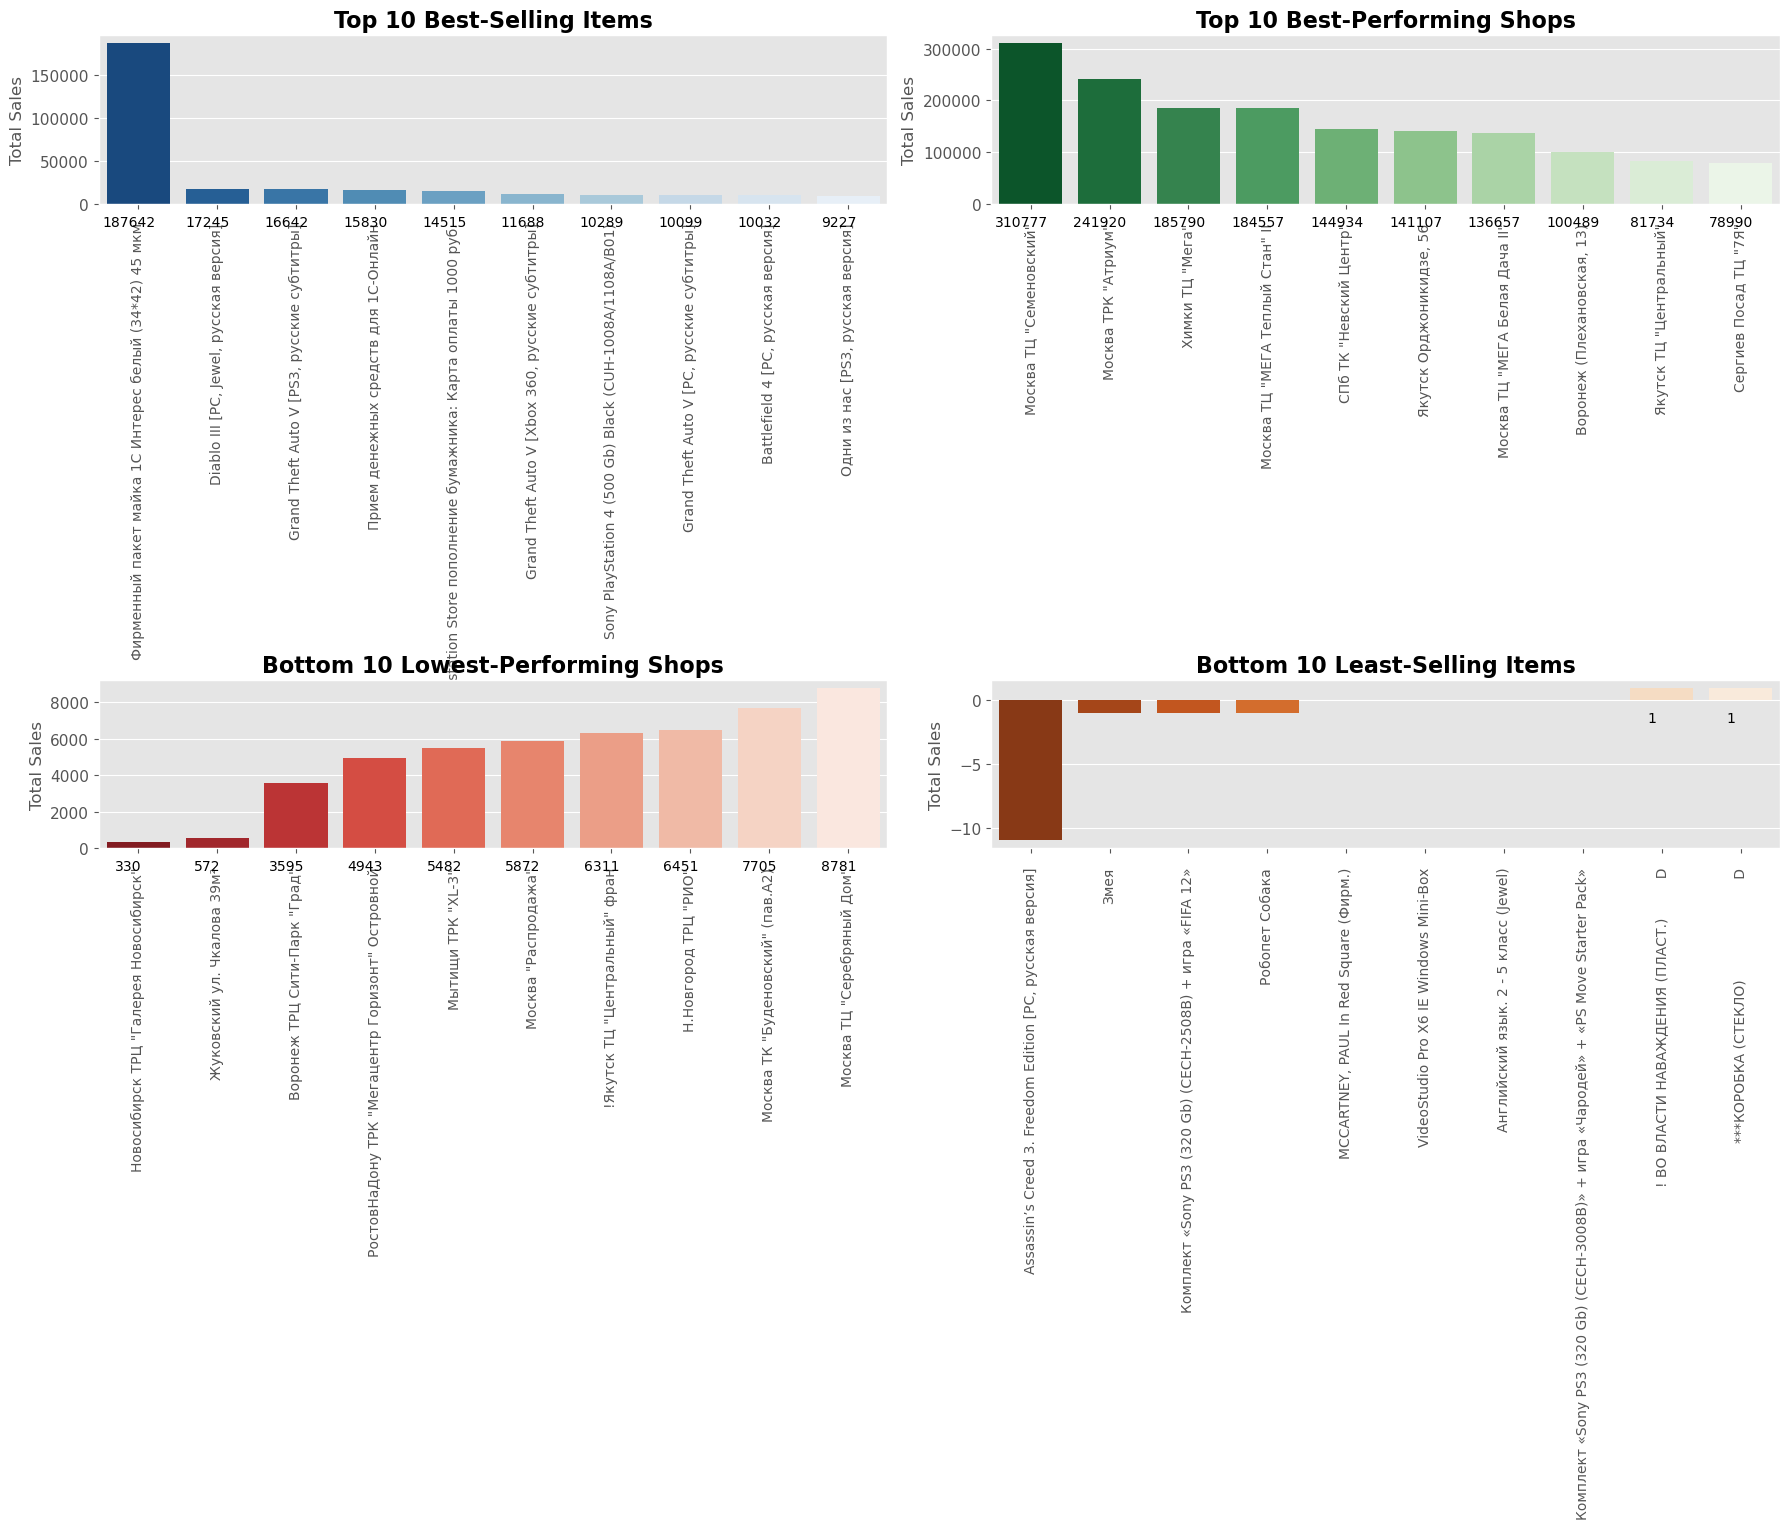

In [10]:
item_sales = df.groupby(['item_id', 'item_name'])['item_cnt_day'].sum().reset_index()
shop_sales = df.groupby(['shop_id', 'shop_name'])['item_cnt_day'].sum().reset_index()

top_items = item_sales.nlargest(10, 'item_cnt_day')
bottom_items = item_sales.nsmallest(10, 'item_cnt_day')
top_shops = shop_sales.nlargest(10, 'item_cnt_day')
bottom_shops = shop_sales.nsmallest(10, 'item_cnt_day')

def annotate_bars_below_left(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            x = p.get_x() + p.get_width() * 0.35
            ax.annotate(f'{int(height)}',
                        (x, 0),
                        ha='center', va='top',
                        fontsize=10,
                        color='black',
                        xytext=(0, -8),
                        textcoords='offset points')

plt.style.use('ggplot')

fig, axs = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(ax=axs[0, 0], data=top_items, x='item_name', y='item_cnt_day', palette='Blues_r')
axs[0, 0].set_title('Top 10 Best-Selling Items', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[0, 0])

sns.barplot(ax=axs[0, 1], data=top_shops, x='shop_name', y='item_cnt_day', palette='Greens_r')
axs[0, 1].set_title('Top 10 Best-Performing Shops', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[0, 1])

sns.barplot(ax=axs[1, 0], data=bottom_shops, x='shop_name', y='item_cnt_day', palette='Reds_r')
axs[1, 0].set_title('Bottom 10 Lowest-Performing Shops', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[1, 0])

sns.barplot(ax=axs[1, 1], data=bottom_items, x='item_name', y='item_cnt_day', palette='Oranges_r')
axs[1, 1].set_title('Bottom 10 Least-Selling Items', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[1, 1])

for ax in axs.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('Total Sales', fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=10, pad=10)
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=2)

for ax in axs[1, :]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.1, pos.width, pos.height])

plt.show()

## Detect trends, seasonality, and cycles

In [12]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df['month'] = df['date'].dt.to_period('M')
monthly_sales = df.groupby('month')['item_cnt_day'].sum().to_timestamp()

### Monthly total sales over time

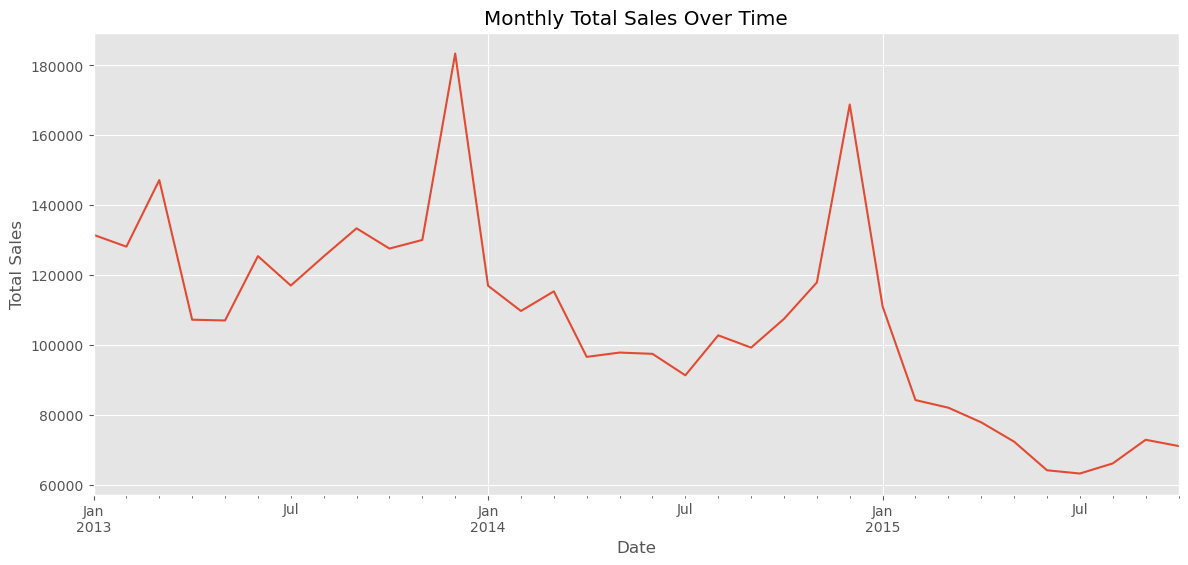

In [13]:
plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Seasonal Decomposition of Sales

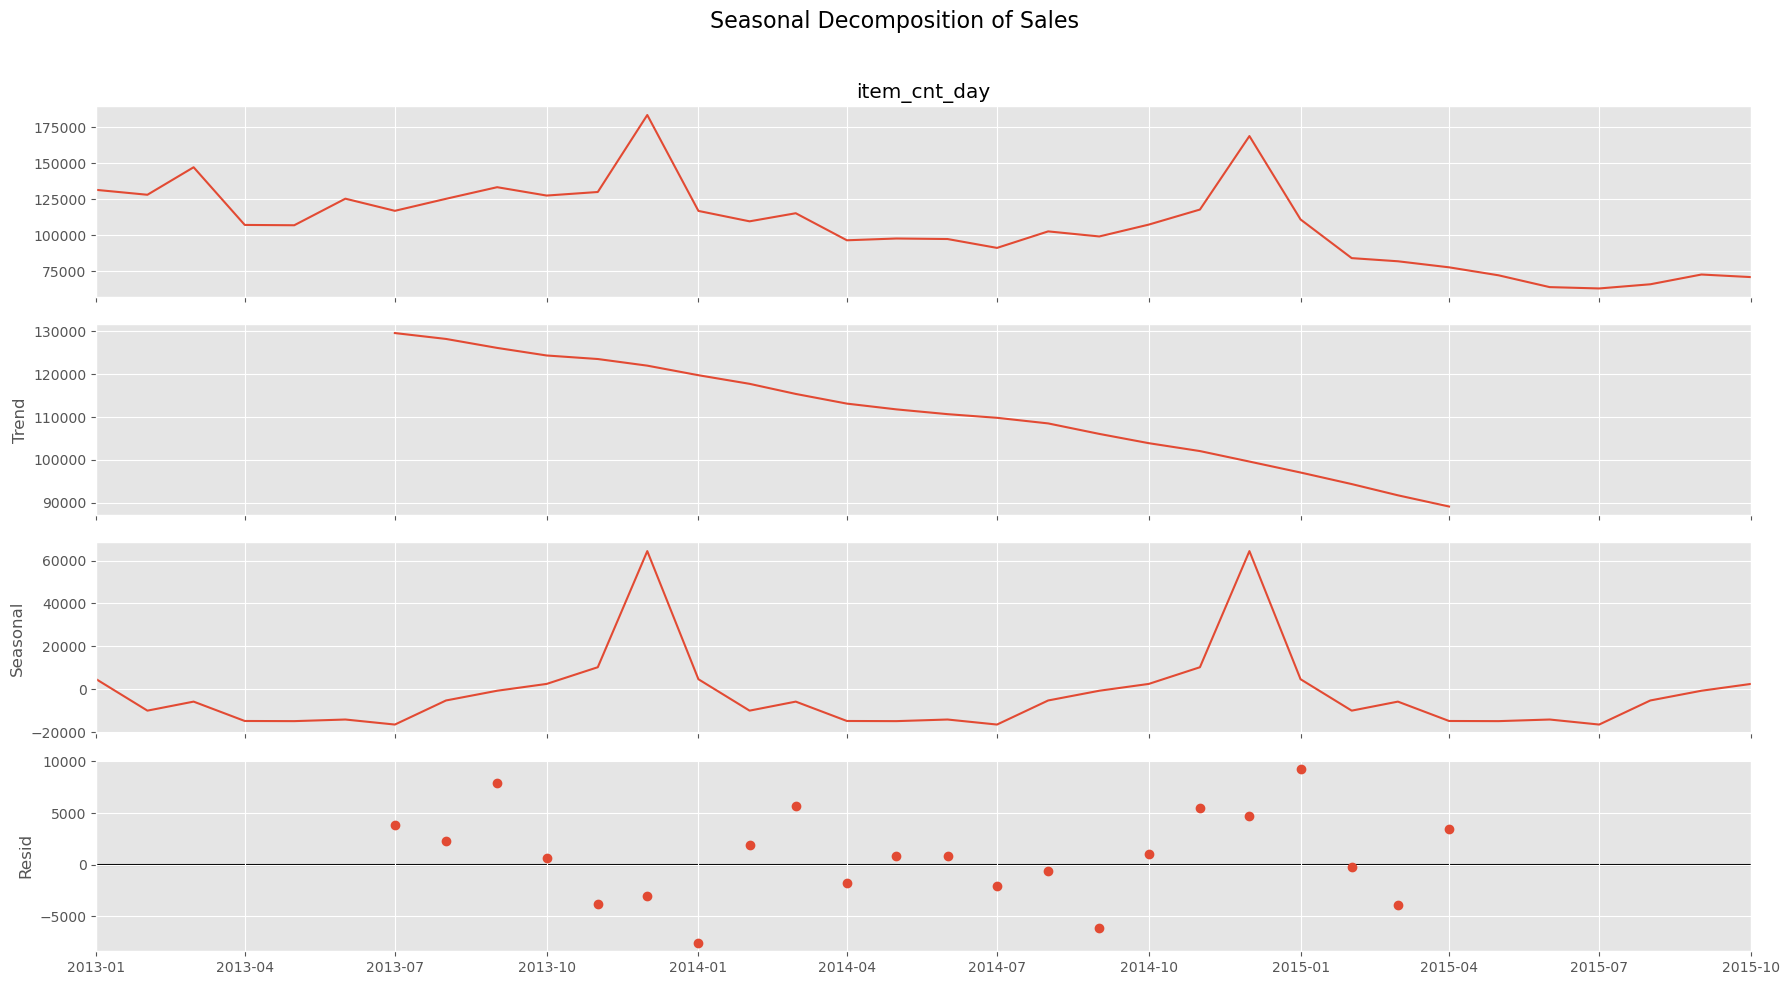

In [14]:
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(18, 10)  
fig.suptitle("Seasonal Decomposition of Sales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

### Autocorrelation of Monthly Sales

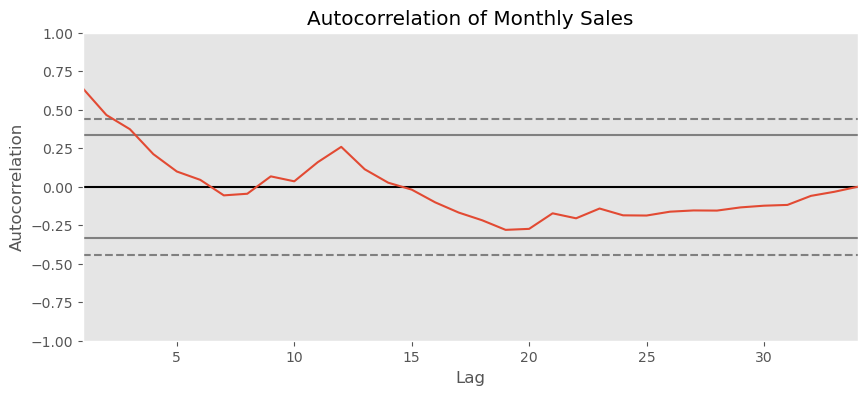

In [15]:
plt.figure(figsize=(10,4))
autocorrelation_plot(monthly_sales)
plt.title("Autocorrelation of Monthly Sales")
plt.show()

### Sales with 3 month Moving Average

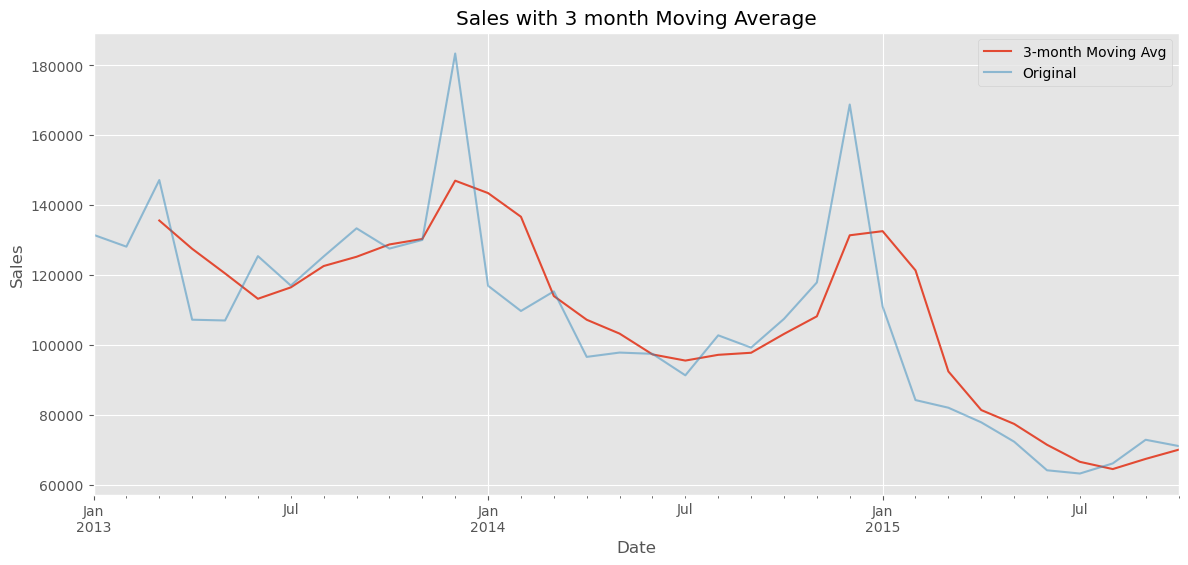

In [16]:
monthly_sales.rolling(window=3).mean().plot(figsize=(14,6), label='3-month Moving Avg')
monthly_sales.plot(alpha=0.5, label='Original')
plt.legend()
plt.title("Sales with 3 month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## Shop-level and item-level sales behavior

C:\Users\SUPER\AppData\Local\Temp\ipykernel_8644\2904007000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shop_sales.values, y=shop_sales.index, palette='mako')


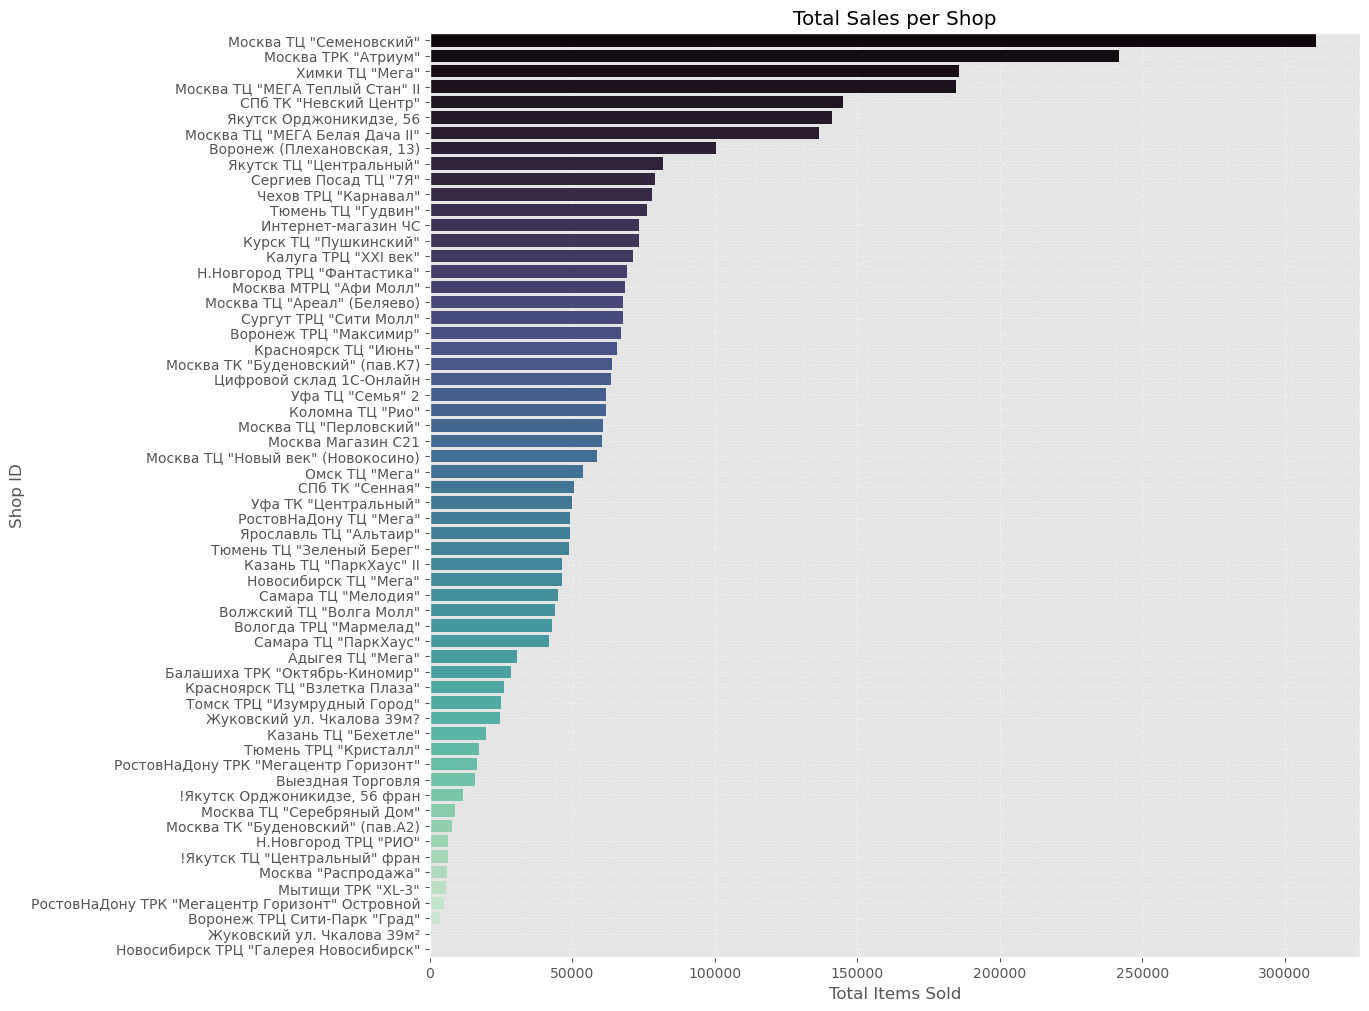

In [17]:
shop_sales = df.groupby('shop_name')['item_cnt_day'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,12))
sns.barplot(x=shop_sales.values, y=shop_sales.index, palette='mako')
plt.title("Total Sales per Shop")
plt.xlabel("Total Items Sold")
plt.ylabel("Shop ID")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Relationship between price and sales volume

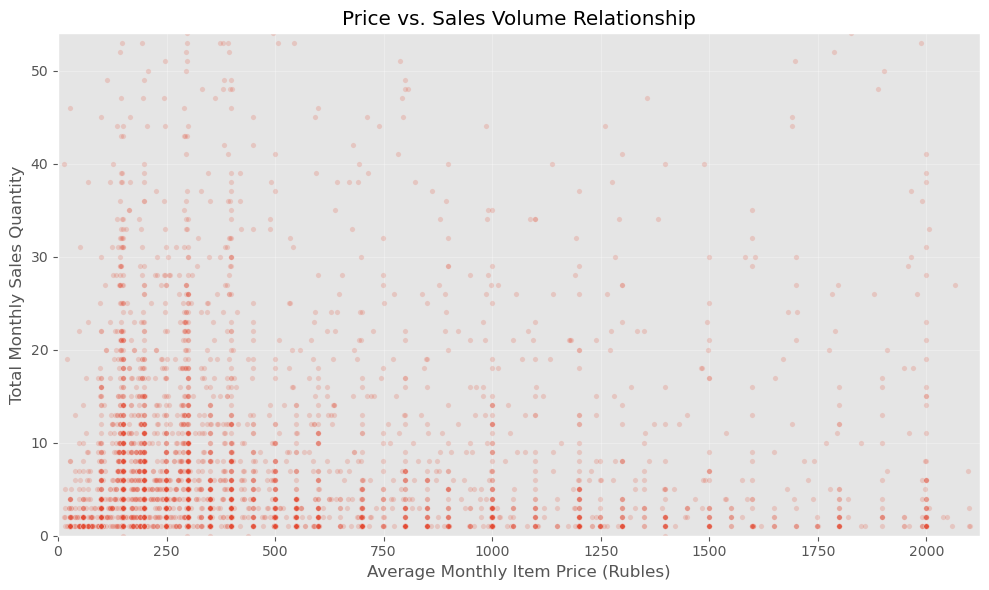

In [18]:
price_sales = df.groupby(['date_block_num', 'item_id']).agg({
    'item_price': 'mean',
    'item_cnt_day': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))  
sns.scatterplot(
    data=price_sales.sample(5000, random_state=42),  
    x='item_price',
    y='item_cnt_day',
    alpha=0.2,
    s=15  
)

plt.title('Price vs. Sales Volume Relationship')
plt.xlabel('Average Monthly Item Price (Rubles)')
plt.ylabel('Total Monthly Sales Quantity')
plt.grid(alpha=0.3)  

plt.ylim(0, price_sales['item_cnt_day'].quantile(0.95))  
plt.xlim(0, price_sales['item_price'].quantile(0.95))  

plt.tight_layout()
plt.show()

In [19]:
corr_price_sales = price_sales[['item_price', 'item_cnt_day']].corr()
print("Correlation between item_price and item_cnt_day\n", corr_price_sales)

Correlation between item_price and item_cnt_day
               item_price  item_cnt_day
item_price      1.000000      0.027607
item_cnt_day    0.027607      1.000000


# Trends depending on shop

In [73]:
pivot_table = pd.pivot_table(
    df,
    values='item_cnt_day',
    index='item_category_id',
    columns='shop_name',
    aggfunc='sum',
    fill_value=0
)

if pivot_table.empty:
    print("Error: Filtered pivot table is empty. Please check the data in df.")
else:
    fig = px.imshow(
        pivot_table,
        labels=dict(x="Shops", y="Product Categories", color="Total Sales"),
        title="Sales Distribution by Product Category and Shop",
        color_continuous_scale='YlGnBu',
        aspect="auto"
    )

    fig.update_xaxes(
        tickangle=45,
        tickfont=dict(size=10),
        title_text="Shop Names"  
    )
    fig.update_yaxes(
        tickfont=dict(size=10),
        title_text="Product Category ID" 
    )
    fig.update_layout(
        width=1200,
        height=800,
        margin=dict(l=100, r=50, t=100, b=100),  
        coloraxis_colorbar_title_text="Total Sales",  
        coloraxis_colorbar_title_font_size=12,
        xaxis_title_font_size=12, 
        yaxis_title_font_size=12
    )

    fig.show()

In [21]:
shop_stats = df.groupby('shop_id')['item_cnt_day'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)
print("Sales statistics by stores (mean and standard deviation):\n", shop_stats)

Sales statistics by stores (mean and standard deviation):
              mean        std
shop_id                     
9        4.229805   7.991928
20       3.276786   4.463307
12       2.117888  16.500692
55       1.823118   8.002811
42       1.326591   2.525446
22       1.325659   1.930389
31       1.318886   2.199277
25       1.299918   2.520718
28       1.297559   1.709054
27       1.296974   2.584001
54       1.294884   2.133040
43       1.288325   2.133466
26       1.259321   1.759337
14       1.254090   1.520023
39       1.236384   1.438989
18       1.230315   1.616501
6        1.215647   1.722364
24       1.204669   2.044555
57       1.201647   1.108850
15       1.196434   2.022066
30       1.195989   1.181002
47       1.192998   1.602960
29       1.192748   1.617463
46       1.191025   1.212625
0        1.187481   0.633668
35       1.180871   1.235158
21       1.179365   1.336703
2        1.178100   1.109728
41       1.175304   1.103336
38       1.171104   1.548275
50       1.16

# Seasonality depending on month

In [22]:
df['month'] = pd.to_datetime(df['date']).dt.month

seasonal_cat = df.groupby(['month', 'item_category_id'])['item_cnt_day'].mean().reset_index()

fig = px.imshow(
    seasonal_cat.pivot(index='item_category_id', columns='month', values='item_cnt_day').fillna(0),
    labels=dict(x="Month", y="Item Category ID", color="Average Daily Sales"),
    title="Seasonal Sales Patterns by Product Category",
    color_continuous_scale='YlGnBu',
    aspect="auto"
)

fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
fig.update_yaxes(tickfont=dict(size=10))
fig.update_layout(
    width=1000,
    height=600,
    margin=dict(l=50, r=50, t=100, b=50),
    coloraxis_colorbar_title_font_size=12,
    xaxis_title="Month",
    yaxis_title="Product Category ID",
    coloraxis_colorbar_title_text="Avg Daily Sales"
)

fig.show()

In [37]:
df[df['item_category_id'] == 9]['shop_name'].unique()

array(['Интернет-магазин ЧС'], dtype=object)

We can see that shop 'Интернет-магазин ЧС' is the only one who sell this category and have extremely good item_cnt_day

Could this mean that it was in high demand and if other stores sold this category it would be a bestseller?

But we can see what non-unique goods this store sold and if they are also high - it's the store's fault

In [44]:
df[df['shop_name'] == 'Интернет-магазин ЧС']['item_category_name'].unique()

array(['Кино - DVD', 'Кино - Blu-Ray 3D',
       'Музыка - CD локального производства', 'Кино - Коллекционное',
       'Игры PC - Дополнительные издания',
       'Игры PC - Стандартные издания', 'Подарки - Развитие',
       'Кино - Blu-Ray', 'Аксессуары - XBOX 360', 'Музыка - MP3',
       'Доставка товара', 'Книги - Методические материалы 1С',
       'Книги - Аудиокниги', 'Книги - Бизнес литература',
       'Подарки - Сувениры (в навеску)', 'Игры - PS3',
       'Подарки - Гаджеты, роботы, спорт', 'Программы - 1С:Предприятие 8',
       'Программы - Для дома и офиса', 'Аксессуары - PSVita',
       'Аксессуары - PS3', 'Музыка - CD фирменного производства',
       'Игры - PSVita', 'Игры - XBOX 360', 'Игры - PSP',
       'Игры PC - Коллекционные издания', 'Игры - Аксессуары для игр',
       'Подарки - Мягкие игрушки', 'Подарки - Сувениры',
       'Подарки - Фигурки', 'Игровые консоли - PS3',
       'Игровые консоли - PSVita', 'Подарки - Настольные игры',
       'Музыка - Музыкальное видео',

In [46]:
top_categories_chs = (
    df[df['shop_name'] == 'Интернет-магазин ЧС']
    .groupby('item_category_name')['item_cnt_day']
    .sum()
    .nlargest(10)  
    .reset_index()
)
top_categories_chs

,item_category_name,item_cnt_day
0,Доставка товара,18118.0
1,Игры PC - Стандартные издания,5189.0
2,Книги - Методические материалы 1С,4312.0
3,Игры - PS4,4016.0
4,Игры - PS3,3784.0
5,Игры PC - Дополнительные издания,2931.0
6,Служебные - Билеты,2896.0
7,Кино - Blu-Ray,2880.0
8,Билеты (Цифра),2771.0
9,Игры PC - Коллекционные издания,2669.0


In [47]:
top_categories_all = (
    df.groupby('item_category_name')['item_cnt_day']
    .sum()
    .nlargest(10)
    .reset_index()
)

print("\nТоп-10 категорий во всех магазинах:")
print(top_categories_all)


Топ-10 категорий во всех магазинах:
                         item_category_name  item_cnt_day
0                                Кино - DVD      634171.0
1             Игры PC - Стандартные издания      456540.0
2       Музыка - CD локального производства      348591.0
3                                Игры - PS3      254887.0
4                            Кино - Blu-Ray      203284.0
5  Подарки - Сумки, Альбомы, Коврики д/мыши      187998.0
6          Игры PC - Дополнительные издания      174954.0
7                           Игры - XBOX 360      169944.0
8                                Игры - PS4      127319.0
9    Подарки - Настольные игры (компактные)       73077.0


But could it be that the store simply didn't have the best products?

In [48]:
categories_in_chs = df[df['shop_name'] == 'Интернет-магазин ЧС']['item_category_name'].unique()

In [54]:
top10_in_chs = (
    df[df['shop_name'] == 'Интернет-магазин ЧС']
    .groupby('item_category_name')['item_cnt_day']
    .sum()
    .nlargest(10)
    .index
    .tolist()
)
print("\nTop 10 best-selling categories in 'Online store CHS':':\n", top10_in_chs)


Top 10 best-selling categories in 'Online store CHS':':
 ['Доставка товара', 'Игры PC - Стандартные издания', 'Книги - Методические материалы 1С', 'Игры - PS4', 'Игры - PS3', 'Игры PC - Дополнительные издания', 'Служебные - Билеты', 'Кино - Blu-Ray', 'Билеты (Цифра)', 'Игры PC - Коллекционные издания']


In [53]:
missing_categories = [cat for cat in top10_in_chs if cat not in categories_in_chs]

if not missing_categories:
    print("\n All top 10 categories are present in the store's assortment.")
else:
    print(f"\n Categories from the top 10 that are not in the assortment were found: {missing_categories}")


 All top 10 categories are present in the store's assortment.


# Conclusion

## Target variables distribution

The chart shows seasonal fluctuations every New Year.

Popular categories: Categories 19, 20, 23, 28, 30, 37, 40, 55, 71 include high-demand items (e.g. seasonal products like electronics before the holidays or clothing during certain seasons).

Categories with low values ​​may be niche or have limited supply in stores.

Branded T-shirt package 1C best-selling product

Sales are concentrated mainly in the gaming and console categories

## Trends, Seasonality

Data is seasonal and have negative trend

Sales have trended downward.

Recurring intra-year patterns drive regular sales cycles.

Autocorrelation indicates sales in any given month influence future months.

## Shops and month sales

The lower the price the higher the demand, because it's essential goods

Moscow stores consistently sell more than others

Month is one of the key factors of sales

## Possible Features

Season, because sales are closely related to the time of year, for example, sales of deliveries drop very sharply in the summer

Month, similar reason

City, because sales are closely linked to the city, and it is necessary to clearly indicate to the model in which city the store is located

Lag because our sales distribution is cyclical and 
the autocorrelation plot shows high values ​​at low lag

Does the store have the best-selling categories in its assortment yes/no, because the best categories sell equally well in all stores

The best-selling category for the store, because it is fundamentally important for us to predict the product that is in the greatest demand

The best selling product, same reason

For low-priced goods you can mark that these are essential goods yes/no